In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from hls4ml_gravnet.utils.data import load_processed

DATAPATH = "/scratch/lasfour/hgcal-clustering/hls4ml-gravnet/data/dataset/toy_calo/toy_calo_processed.h5"

D = load_processed(DATAPATH)

data = {
    "X" : np.concatenate([D["X_hits_train"], D["X_hits_test"]], axis=0),
    "y_energy" : np.concatenate([D["y_energy_train"], D["y_energy_test"]], axis=0),
    "y_pid" : np.concatenate([D["y_pid_train"], D["y_pid_test"]], axis=0)
}

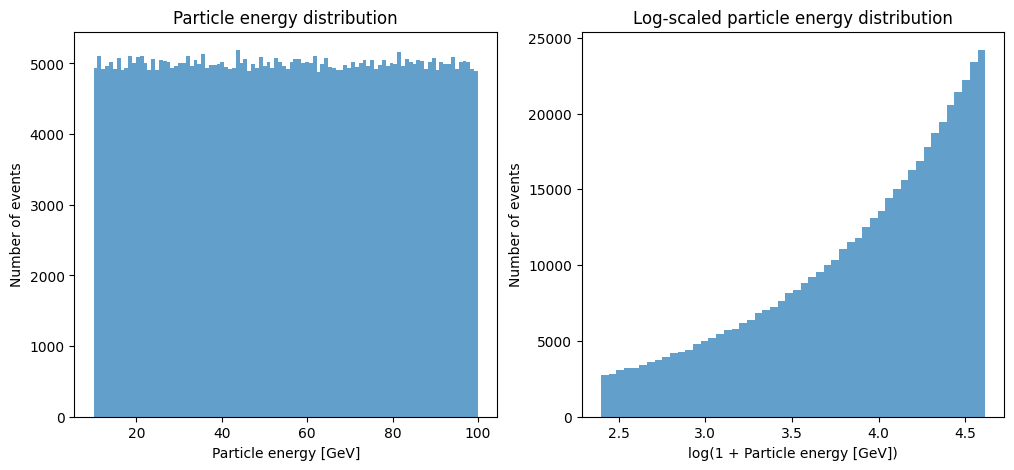

In [2]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.hist(data["y_energy"], bins=100, alpha=0.7)
plt.xlabel("Particle energy [GeV]")
plt.ylabel("Number of events")
plt.title("Particle energy distribution")

plt.subplot(1,2,2)
plt.hist(np.log1p(data["y_energy"]), bins=50, alpha=0.7)
plt.xlabel("log(1 + Particle energy [GeV])")
plt.ylabel("Number of events")
plt.title("Log-scaled particle energy distribution")
plt.show()

## Distributions

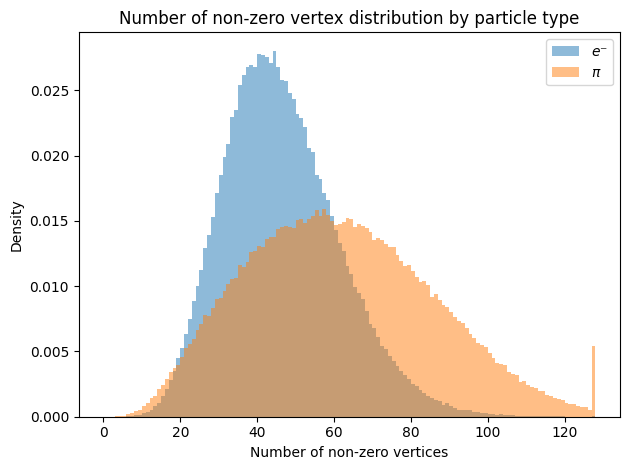

In [3]:
df = pd.DataFrame({
    "energy": data["y_energy"].flatten(),
    "pid": data["y_pid"].flatten(),
    "non_zero_vtx" : np.sum(np.any(data["X"] != 0, axis=2), axis=1)
})

# plt.figure(figsize=(15,6))
# plt.subplot(1,2,1)
# plt.hist(df[df.pid ==0].energy, bins=50, alpha=0.5, label="$e⁻$", density=True)
# plt.hist(df[df.pid ==1].energy, bins=50, alpha=0.5, label="$π$", density=True)
# plt.xlabel("Particle energy [GeV]")
# plt.ylabel("Density")
# plt.legend()
# plt.title("Particle energy distribution")

# plt.subplot(1,2,2)
bins = np.arange(0, 129, 1)
plt.hist(df[df.pid ==0].non_zero_vtx, bins=bins, alpha=0.5, label="$e⁻$", density=True)
plt.hist(df[df.pid ==1].non_zero_vtx, bins=bins, alpha=0.5, label="$π$", density=True)
plt.xlabel("Number of non-zero vertices")
plt.ylabel("Density")
plt.legend()
plt.title("Number of non-zero vertex distribution by particle type")

plt.tight_layout()
plt.show()


## Truncation effects 

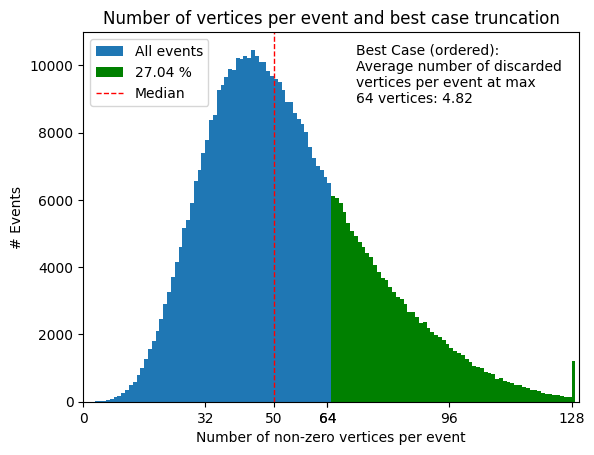

In [4]:
MAX_VERTICES =  64

number_of_nonzero_vertices = np.sum(np.any(data["X"] != 0, axis=2), axis=1)
cts, bins, patches = plt.hist(number_of_nonzero_vertices, bins=np.arange(0, 130, 1), label='All events')


plt.hist(number_of_nonzero_vertices[number_of_nonzero_vertices > MAX_VERTICES], bins=bins, color='g', label=f'{np.sum(number_of_nonzero_vertices > MAX_VERTICES) / len(number_of_nonzero_vertices) * 100:.2f} %')
plt.axvline(np.median(number_of_nonzero_vertices), color='r', linestyle='dashed', linewidth=1, label='Median')
plt.xlabel("Number of non-zero vertices per event")
plt.xticks([0, 32, 64, 96, 128, np.median(number_of_nonzero_vertices), MAX_VERTICES])
plt.xlim(0, 130)
plt.ylabel("# Events")
plt.legend(loc='upper left')

avg_discarded_str = f"Best Case (ordered):\nAverage number of discarded\nvertices per event at max\n{MAX_VERTICES} vertices: {np.mean(np.maximum(number_of_nonzero_vertices - MAX_VERTICES, 0)):.2f}"
plt.text(.55, .97, avg_discarded_str, transform=plt.gca().transAxes, fontsize=10, verticalalignment='top', horizontalalignment='left')
plt.title("Number of vertices per event and best case truncation")

plt.show()


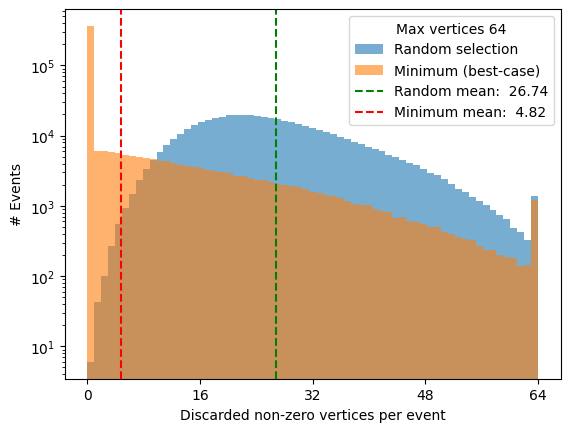

In [5]:
rng = np.random.default_rng(seed=42)

X = np.stack(data["X"])
N_events, N_vertices, _ = X.shape

perm = np.argsort(rng.random((N_events, N_vertices)), axis=1) 
kept = perm[:, :MAX_VERTICES] # first max_vertices after shuffle

nonzero_mask = np.any(X != 0, axis=2)    # (N_events, N_vertices)
kept_nonzero = np.take_along_axis(
    nonzero_mask, kept, axis=1
).sum(axis=1)

total_nonzero = nonzero_mask.sum(axis=1)

# Minimum (best-case) discarded
min_discarded = np.maximum(total_nonzero - MAX_VERTICES, 0)

# Random discarded
random_discarded = total_nonzero - kept_nonzero

plt.hist( random_discarded, bins=65, alpha=0.6, label="Random selection" ) 
plt.hist( min_discarded, bins=65, alpha=0.6, label="Minimum (best-case)" ) 
plt.axvline(np.mean(random_discarded), color="g", linestyle="--", label=f"Random mean:  {np.mean(random_discarded):.2f}") 
plt.axvline(np.mean(min_discarded), color="r", linestyle="--", label=f"Minimum mean:  {np.mean(min_discarded):.2f}") 
plt.xlabel("Discarded non-zero vertices per event") 
plt.xticks([0, 16, 32, 48, 64])
plt.ylabel("# Events") 
plt.yscale("log") 
plt.legend(title=f"Max vertices {MAX_VERTICES}") 
plt.show()